In [3]:
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv("placement.csv")

In [5]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [6]:
df.shape

(100, 4)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [8]:
 df=df.iloc[:,1:] #not the 0th col

In [9]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [10]:
import matplotlib.pyplot as plt

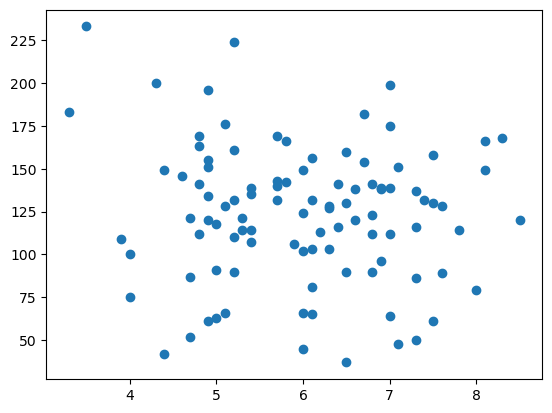

In [13]:
plt.scatter(df['cgpa'],df['iq'])

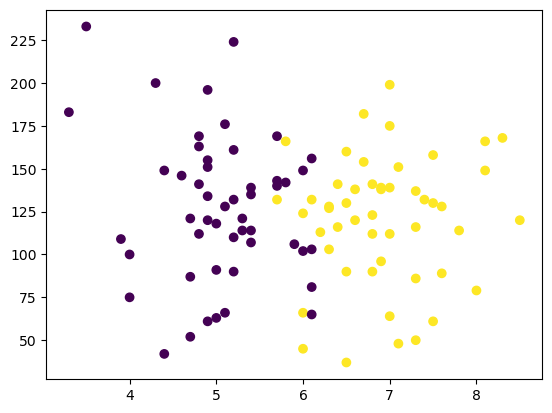

In [14]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [20]:
#independent variables
x=df.iloc[:,0:2]
#dependent
y=df.iloc[:,-1]

In [17]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [18]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [19]:
y.shape

(100,)

In [21]:
from sklearn.model_selection import train_test_split

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [24]:
x_train

,cgpa,iq
9,5.1,66.0
57,6.5,130.0
17,3.3,183.0
54,6.4,141.0
88,4.4,149.0
...,...,...
31,3.9,109.0
43,6.8,141.0
64,7.0,64.0
92,5.2,110.0


In [25]:
y_train

9     0
57    1
17    0
54    1
88    0
     ..
31    0
43    1
64    1
92    0
11    1
Name: placement, Length: 90, dtype: int64

In [26]:
x_test

,cgpa,iq
20,6.6,120.0
68,4.0,75.0
69,8.5,120.0
8,6.1,156.0
95,4.3,200.0
60,6.9,139.0
4,5.8,142.0
98,6.3,103.0
25,5.0,91.0
15,5.1,176.0


In [27]:
from sklearn.preprocessing import StandardScaler


In [28]:
scaler=StandardScaler()

In [31]:
x_train=scaler.fit_transform(x_train)

In [32]:
x_train

array([[-0.80734829, -1.41659302],
       [ 0.44082207,  0.18457962],
       [-2.41213874,  1.51055072],
       [ 0.35166704,  0.45978117],
       [-1.43143346,  0.65992775],
       [-0.62903823, -0.21571354],
       [ 0.44082207, -2.14212438],
       [ 0.8865972 ,  1.31040414],
       [-1.25312341,  0.58487279],
       [ 0.8865972 ,  0.40974453],
       [-1.07481336,  1.16029421],
       [ 0.70828715,  0.00945137],
       [-1.07481336, -0.26575018],
       [ 0.08420197,  0.23461627],
       [ 0.97575222, -1.86692283],
       [-1.16396839, -0.89120825],
       [-0.89650331, -1.49164799],
       [-0.09410808, -0.41586012],
       [-0.98565834,  0.7099644 ],
       [ 0.61913212,  1.4855324 ],
       [ 0.17335699, -0.24073186],
       [ 0.08420197, -1.04131818],
       [-0.98565834,  0.28465291],
       [ 2.04561253,  1.13527588],
       [ 0.5299771 ,  0.38472621],
       [ 0.44082207, -0.81615328],
       [ 1.33237232, -1.54168463],
       [-0.80734829,  0.13454298],
       [ 0.35166704,

In [33]:
x_test=scaler.transform(x_test)

In [34]:
x_test

array([[ 0.5299771 , -0.0656036 ],
       [-1.78805357, -1.19142812],
       [ 2.22392258, -0.0656036 ],
       [ 0.08420197,  0.83505601],
       [-1.52058849,  1.93586221],
       [ 0.79744217,  0.40974453],
       [-0.18326311,  0.4847995 ],
       [ 0.26251202, -0.49091509],
       [-0.89650331, -0.79113496],
       [-0.80734829,  1.33542246]])

In [35]:
from sklearn.linear_model import LogisticRegression


In [37]:
clf=LogisticRegression()

In [38]:
#model training
clf.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [41]:
y_pred=clf.predict(x_test)

In [42]:
y_test

20    1
68    0
69    1
8     0
95    0
60    1
4     0
98    1
25    0
15    0
Name: placement, dtype: int64

In [43]:
from sklearn.metrics import accuracy_score

In [44]:
accuracy_score(y_test,y_pred)

0.9

In [57]:
%pip install mlxtend
from mlxtend.plotting import plot_decision_regions

  Using cached mlxtend-0.25.0-py3-none-any.whl.metadata (7.4 kB)
Using cached mlxtend-0.25.0-py3-none-any.whl (1.4 MB)
Note: you may need to restart the kernel to use updated packages.


<Axes: >

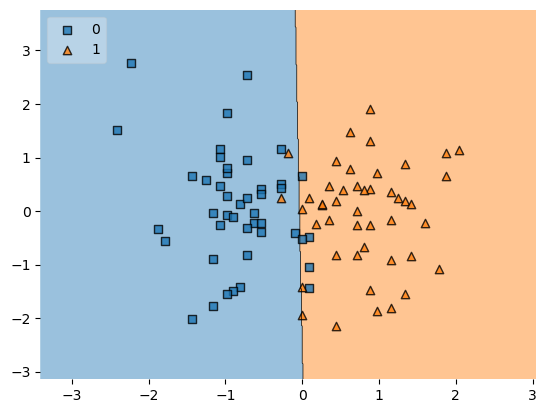

In [58]:
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)

In [61]:
import pickle

In [62]:
pickle.dump(clf,open('model.pkl','wb'))